# ENGR 1451/2451 — Weekly Assignment 4
**10 points**

This assignment applies measurement-error ideas, pandas data manipulation, and scatterplots and time trends.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.

## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.

## Setup

All data are synthetic teaching examples. LE4-1 and LE4-2 use data embedded in this notebook.
For LE4-3 and LE4-4, place the supplied `buildings.csv` file in a `data/` subfolder beside this notebook:

```text
LE04.ipynb
data/
    buildings.csv
```

Run the notebook with its containing folder as the working directory so that
`data/buildings.csv` points to the supplied file.

Use sample standard deviation $s$ (`ddof=1`). Select rows by conditions, not row positions,
and calculate counts and the latest year from the data. Use the supplied settings for thresholds.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

## LE4-1. Comparing two measuring instruments (2 pts)

Two instruments repeatedly measure the same reference block. Treat its certified length,
**25.000 mm**, as exact for this exercise.

### A. Precision and estimated bias (1 pt)

Create a table showing the **mean**, **sample standard deviation**, and **estimated bias**
for each instrument. Here, estimated bias is the sample mean minus the reference length.
Which instrument is more precise? Which sample mean is closer to the reference?

**Answer:**
Instrument A is more precist because its standard deviation is smaller. Instrument A is closer to the mean ad has a smaller bias.

In [2]:
reference_mm = 25.000
calibration = pd.DataFrame({
    "A_mm": [25.12, 25.10, 25.14, 25.11, 25.13,
             25.09, 25.12, 25.11, 25.13, 25.10],
    "B_mm": [24.92, 25.06, 24.97, 25.12, 24.89,
             25.03, 25.08, 24.95, 25.00, 24.98],
})

# Your summary table here. Report lengths, s, and estimated bias in mm.
summary = pd.DataFrame({
    "mean_mm": calibration.mean(),
    "samplestd_mm": calibration.std(),
    "estimaded_bias" : calibration.mean() - reference_mm
})
summary 

,mean_mm,samplestd_mm,estimaded_bias
A_mm,25.115,0.015811,0.115
B_mm,25.000,0.072725,0.000


### B. Apply a calibration correction (1 pt)

Subtract A's estimated bias from every A reading and store the result in `corrected_A`.
Compare its mean and sample $s$ with the original A readings.

What changed, and what stayed the same? Would simply collecting more **uncorrected**
readings remove a persistent bias?

**Answer:**
After being corrected, instrument A had its mean changed to 25mm. The standard deviation stayed relatively the same. Collecting more readings would not remove the bias.

In [3]:
# Your correction and comparison here
bias_a = calibration["A_mm"].mean() - reference_mm
corrected_A = calibration["A_mm"] - bias_a
comparison = pd.DataFrame({
    "original_A":[
        calibration["A_mm"].mean(),
        calibration["A_mm"].std()
    ], 
    "corrected_A":[
        corrected_A.mean(),
        corrected_A.std()
    ]
}, index = ["mean_mm", "sample_s_mm"])

comparison

,original_A,corrected_A
mean_mm,25.115000,25.000000
sample_s_mm,0.015811,0.015811


## LE4-2. Investigating unusual resistance readings (3 pts)

An instrument repeatedly measures the same nominal 100-ohm resistor under stable conditions.
Its exact resistance is unknown. An independent equipment log documents a **loose electrical
lead during one reading**; the other readings have no documented fault.

### A. Flag observations for investigation (1 pt)

Calculate $Q_1$, $Q_3$, and the IQR. Flag readings outside
$[Q_1-1.5\,\mathrm{IQR},\ Q_3+1.5\,\mathrm{IQR}]$ with a Boolean mask called `is_outlier`.
Display their reading IDs, resistance values, and log status. Use `.loc[]` and retain the original data.

In [4]:
resistance_values = np.array([
    100.1, 99.9, 100.0, 100.2, 100.1, 99.8, 100.0, 100.1, 102.4, 99.9,
    100.2, 100.0, 99.8, 100.1, 100.0, 100.2, 100.1, 101.1, 99.9, 100.0,
])
log_status = [
    "none", "none", "none", "none", "none", "none", "none", "none", "loose_lead", "none",
    "none", "none", "none", "none", "none", "none", "none", "none", "none", "none",
]
readings = pd.DataFrame({
    "reading_id": [f"R{number:02d}" for number in range(1, len(resistance_values) + 1)],
    "resistance_ohm": resistance_values,
    "log_status": log_status,
})
resistance_settings = {
    "outlier_multiplier": 1.5,
    "fault_status": "loose_lead",
    "lower_ohm": 99.8,
    "upper_ohm": 100.2,
}

# Your IQR calculation, Boolean mask, and flagged-reading table here
Q1 = readings["resistance_ohm"].quantile(0.25)
Q3 = readings["resistance_ohm"].quantile(0.75)
iqr = Q3-Q1
lower = Q1 - resistance_settings["outlier_multiplier"]*iqr
upper = Q3 + resistance_settings["outlier_multiplier"]*iqr

is_outlier = (
    (readings["resistance_ohm"] < lower)|
    (readings["resistance_ohm"] > upper)
)
readings.loc[
    is_outlier,
    ["reading_id", "resistance_ohm", "log_status"]
]

,reading_id,resistance_ohm,log_status
8,R09,102.4,loose_lead
17,R18,101.1,none


### B. Exclude a documented failure (1 pt)

Create `retained_readings` by excluding **only the reading with the logged loose lead**.
Select it by `log_status`, not by its row position or resistance value.
Compare the count, mean, and sample $s$ for all readings and the retained readings in one table.

Compare the absolute changes, in ohms, in the mean and $s$. Which is larger?
Does an IQR flag alone justify excluding the other unusual reading? Explain briefly.

**Answer:**
the mean slightly decreased after removing the loose lead reading. The standard deviation almost halved as well. The change in std was larger. An iqr flag does not justify excluding other unusual readings because all it does is identify a value that should be looked out it doesn't neccessarily mean that the measurement has no validity. 

In [5]:
# Your retained subset and summary comparison here
retained_readings = readings.loc[
    readings["log_status"] != resistance_settings["fault_status"]
]
comparison = pd.DataFrame({
    "all_readings":[
    readings["resistance_ohm"].count(),
    readings["resistance_ohm"].mean(),
    readings["resistance_ohm"].std()
    ],
    "retained_readings" : [
    retained_readings["resistance_ohm"].count(),
    retained_readings["resistance_ohm"].mean(),
    retained_readings["resistance_ohm"].std()
    ]
}, index = ["count", "mean", "sample_s"])
comparison

,all_readings,retained_readings
count,20.000000,19.000000
mean,100.195000,100.078947
sample_s,0.584425,0.276041


### C. Check a normal approximation (1 pt)

Use **all retained readings from Part B**, including any still flagged by the IQR rule.
Fit a normal model using their calculated mean and sample $s$.

For the interval **99.8 to 100.2 ohms, including both endpoints**, report the observed
percentage using a Boolean mask and the normal-model percentage using `norm.cdf()`.
Is the model percentage too low, too high, or close for this interval?
Why would even a good normal fit fail to establish that the instrument is unbiased?

**Answer:**
94.74% of the retained readings are between 99.8 and 100.2 while the fitted model predicts about 50%. The model percentage is way too low fot his interval.  Bias can only be determined by looking at different measurements with some sort of reference value. 

In [6]:
# Your observed percentage and normal approximation 
mean_retained = retained_readings["resistance_ohm"].mean()
retained_std = retained_readings["resistance_ohm"].std()
interval = (
    (retained_readings["resistance_ohm"] >= resistance_settings["lower_ohm"]) & 
    (retained_readings["resistance_ohm"] <= resistance_settings["upper_ohm"])
)
observed_percent = interval.mean()*100
model = (
    norm.cdf(
        resistance_settings["upper_ohm"],
        loc = mean_retained,
        scale = retained_std
    )
    -
    norm.cdf(
        resistance_settings["lower_ohm"],
        loc = mean_retained,
        scale = retained_std
    )
)*100

observed_percent, model
                            
                                                                                                                          

(94.73684210526315, 51.33778920512899)

## LE4-3. Build an electricity-use comparison table (3 pts)

Each row in `data/buildings.csv` describes **one building in one year**. `floor_area_m2` is floor area in
square meters, and `electricity_kWh` is total electricity used during that year.

### A. Create a column and select a year (1 pt)

Run the code below to read `data/buildings.csv` into `buildings`.
Use `.assign()` to create a DataFrame called `energy`
with a new column, `energy_intensity`, calculated as

$$
\text{energy intensity} = \frac{\text{electricity use (kWh)}}{\text{floor area (m}^2\text{)}}.
$$

Find the latest year in the data and create `latest`, a copy containing that year only.
Display building name, use, floor area, and energy intensity for this snapshot.

In [7]:
buildings = pd.read_csv("data/buildings.csv")

energy_settings = {
    "minimum_area_m2": 3000,
    "high_intensity_kWh_m2": 180,
    "trend_building": "Maple",
}

# Your derived column, latest-year selection, and display here
energy = buildings.assign(
    energy_intensity = buildings["electricity_kWh"] / buildings["floor_area_m2"]
)

latest_year = energy["year"].max()
latest = energy.loc[
    energy["year"] == latest_year
].copy()
latest[
    ["building","use", "floor_area_m2", "energy_intensity"]
]

,building,use,floor_area_m2,energy_intensity
0,Birch,Office,400,160.0
3,Cedar,Laboratory,1200,190.0
6,Maple,Office,3200,110.0
9,Oak,Laboratory,8000,220.0
12,Pine,Office,16000,90.0
15,Willow,Laboratory,32000,190.0


### B. Filter and sort (1 pt)

From `latest`, select buildings with floor area **at least 3,000 m²** and energy intensity
**greater than 180 kWh/m²** for the year. Use a compound Boolean condition with `.loc[]`.
Show `building`, `use`, and `energy_intensity`, sorted from highest to lowest intensity.

In [8]:
# Your filtered and sorted table here
filtered = latest.loc[
    (latest["floor_area_m2"] >= energy_settings["minimum_area_m2"]) &
    (latest["energy_intensity"] > energy_settings["high_intensity_kwh_m2"]),
    ["building", "use", "energy_intensity"]
].sort_values(
    "energy_intensity",
    ascending=False
)

filtered

### C. Group and summarize (1 pt)

Using **all buildings in `latest`**, create one row per building `use` with the number
of buildings and mean energy intensity. Use `.groupby(...).agg(...)` with descriptive column names.

Which use has the larger mean? Does this calculation give equal weight to each building
or to each square meter of floor area?

**Answer:**
the labratory has the higher mean energy intensity. It does give equal weight to each building becuase the area isn't accounted for in the mean.

In [18]:
# Your grouped summary here
use_summary = (
    latest.groupby("use")
    .agg(
        building_count=("building", "count"),
        mean_energy_intensity=("energy_intensity", "mean")
    )
    .reset_index()
)

use_summary

,use,building_count,mean_energy_intensity
0,Laboratory,3,200.0
1,Office,3,120.0


## LE4-4. Show a relationship and a time trend (2 pts)

Use `energy` and `latest` from LE4-3. Label axes with units and give each plot a title.

### A. Scatterplot with a log axis (1 pt)

For **all buildings in `latest`**, plot floor area on the x-axis and energy intensity
on the y-axis. Use `ax.set_xscale("log")` because floor areas span a wide range.

Explain what equal horizontal distances represent. Does the largest building have the
highest energy intensity in this snapshot?

**Answer:**
equal horizontal distances represent the changes in unites from 100 to 1,000m^2
and no the largest building does not have the highest energy intensity. 

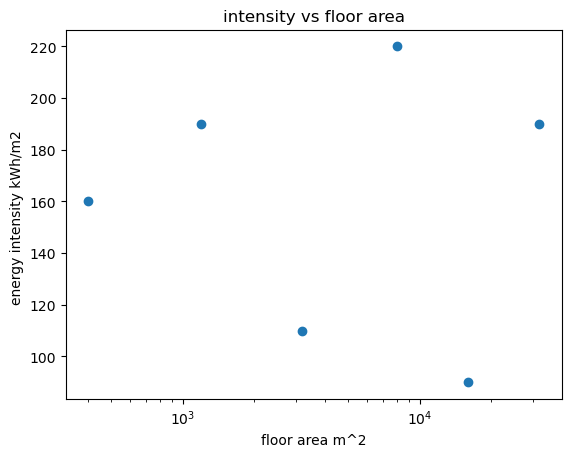

In [10]:
# Your scatterplot here
fig, ax = plt.subplots()
ax.scatter(
    latest["floor_area_m2"],
    latest["energy_intensity"]
)
ax.set_xscale("log")
ax.set_xlabel("floor area m^2")
ax.set_ylabel("energy intensity kWh/m2 ")
ax.set_title("intensity vs floor area")
plt.show()

### B. Follow one building over time (1 pt)

From the full `energy` table, select the building named in `energy_settings["trend_building"]`.
Sort its rows by year before making a line plot of energy intensity versus year, with a marker
at each observed year. Use a linear year axis.

Describe the trend. Would this plot alone establish that an energy-saving renovation caused
the change? Give one reason for your answer.

**Answer:**
the energy decreases linearly from 150 to 130 and then 110. This alone cannot establish tha tan energy saving renovation caused the change because there are a multitude of of factors that could have influenced this. 

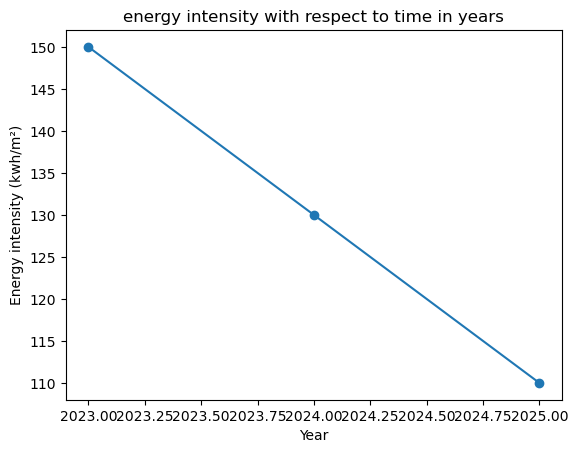

In [17]:
# Your selected, sorted data and time plot here
trend = energy.loc[
    energy["building"] == energy_settings["trend_building"]
].sort_values("year")

trend

fig, ax = plt.subplots()

ax.plot(
    trend["year"],
    trend["energy_intensity"],
    marker = "o"
)

ax.set_xlabel("Year")
ax.set_ylabel("Energy intensity (kwh/m²)")
ax.set_title("energy intensity with respect to time in years")
plt.show()

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.